# Credit Card Fraud Detection — Imbalanced Classification with Threshold Optimisation


## Step 1 - Theory

The first part of the practical focuses on problem framing.
In fraud detection, the business cost of missing fraud is much higher than the comfort of reporting a high overall accuracy number.
That is why the theory below is written from both a machine learning and business point of view.

### 1. Why Accuracy is a Bad Metric for Fraud Detection

Accuracy is not a good metric here because the dataset is extremely imbalanced.
If almost every transaction is legitimate, a model can predict everything as not fraud and still get very high accuracy.
But that model will miss real fraud cases, so it is not useful in practice.
For this problem, Precision, Recall, F1-score, and PR-AUC are more meaningful.

### 2. Precision vs Recall Tradeoff

Precision tells us out of the transactions predicted as fraud, how many were actually fraud.
Recall tells us out of all actual fraud transactions, how many the model successfully caught.
If we lower the threshold from 0.5 to 0.2, the model usually flags more transactions as fraud.
So Recall generally increases, but Precision may decrease because false alarms also increase.

### 3. Random Undersampling, SMOTE, and Class Weight

**Random Undersampling** reduces the number of majority-class rows. It is simple and fast, but it can remove useful information from the dataset.

**SMOTE** creates synthetic minority-class samples. It helps the model learn more fraud-like patterns, but the new points are artificial and can sometimes add noise.

**Class Weight** gives more penalty to mistakes on the fraud class during training. It keeps all the original data, but with extreme imbalance it may still not be enough on its own.

### 4. PR-AUC and Why It is Preferred Over ROC-AUC

PR-AUC focuses on Precision and Recall for the fraud class, which is the class we care about most.
This makes it more useful when the positive class is very rare.
ROC-AUC can still look good in imbalanced datasets because true negatives are easy to get.
So for fraud detection, PR-AUC gives a better picture of actual minority-class performance.

### 5. False Positive vs False Negative with Business Impact

A False Positive means a genuine transaction is flagged as fraud. This creates customer inconvenience and extra review cost.
A False Negative means a fraud transaction is missed. This leads to direct money loss for the company.
In fraud detection, False Negatives are usually more costly, but too many False Positives also create operational problems.

## Import Library

In [407]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display


from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              average_precision_score, precision_recall_curve,
                              confusion_matrix)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
import joblib


## Step 2: Dataset Loading & EDA

In [408]:
df=pd.read_csv("creditcard.csv")
print(df.shape)
print(df['Class'].value_counts(normalize=True))

sample,_=train_test_split(df,train_size=50000,stratify=df['Class'],random_state=42)
print(sample.describe())


(284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64
               Time            V1            V2            V3            V4  \
count   50000.00000  50000.000000  50000.000000  50000.000000  50000.000000   
mean    94977.93554      0.001813     -0.003654     -0.002152      0.007657   
std     47475.50731      1.964773      1.656783      1.510070      1.412869   
min         0.00000    -46.855047    -48.060856    -31.103685     -5.519697   
25%     54423.50000     -0.916605     -0.601309     -0.893155     -0.832265   
50%     84852.00000      0.025321      0.069204      0.176578     -0.016589   
75%    139392.25000      1.316058      0.804474      1.021558      0.746497   
max    172787.00000      2.420346     22.057729      4.101716     13.129143   

                 V5            V6            V7            V8            V9  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.012340      0.000112     -0.008224   

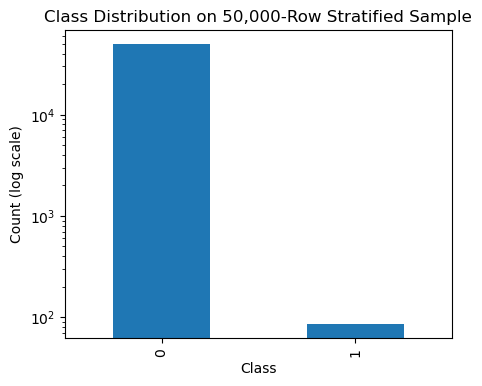

In [409]:
plt.figure(figsize=(5,4))
plt.title("Class Distribution on 50,000-Row Stratified Sample")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
sample['Class'].value_counts().plot(kind='bar',logy=True)
plt.show()

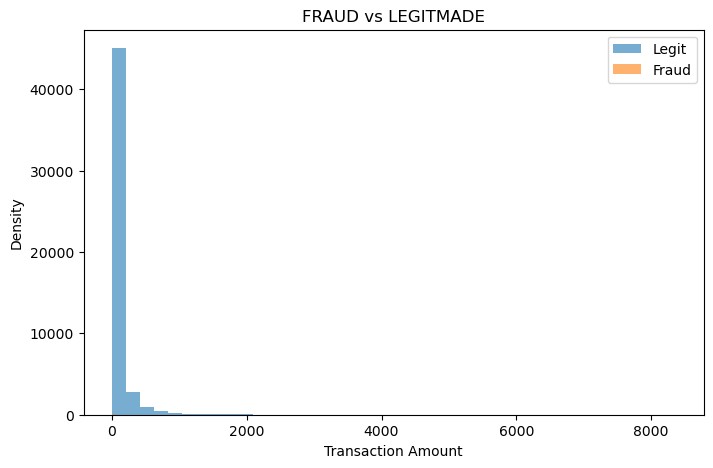

In [410]:
plt.figure(figsize=(8,5))
plt.title("FRAUD vs LEGITMADE")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.hist(sample[sample.Class==0]['Amount'],bins=40,alpha=.6,label='Legit')
plt.hist(sample[sample.Class==1]['Amount'],bins=40,alpha=.6,label='Fraud')
plt.legend(); plt.show()

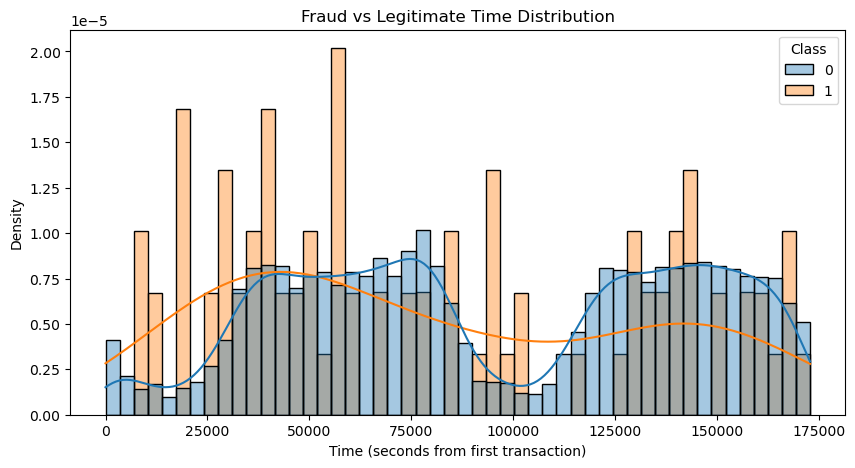

In [411]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=sample,
    x="Time",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.4,
)
plt.title("Fraud vs Legitimate Time Distribution")
plt.xlabel("Time (seconds from first transaction)")
plt.ylabel("Density")
plt.show()

fraud_hour = ((sample.loc[sample["Class"] == 1, "Time"] % 86400) // 3600).median()
legit_hour = ((sample.loc[sample["Class"] == 0, "Time"] % 86400) // 3600).median()



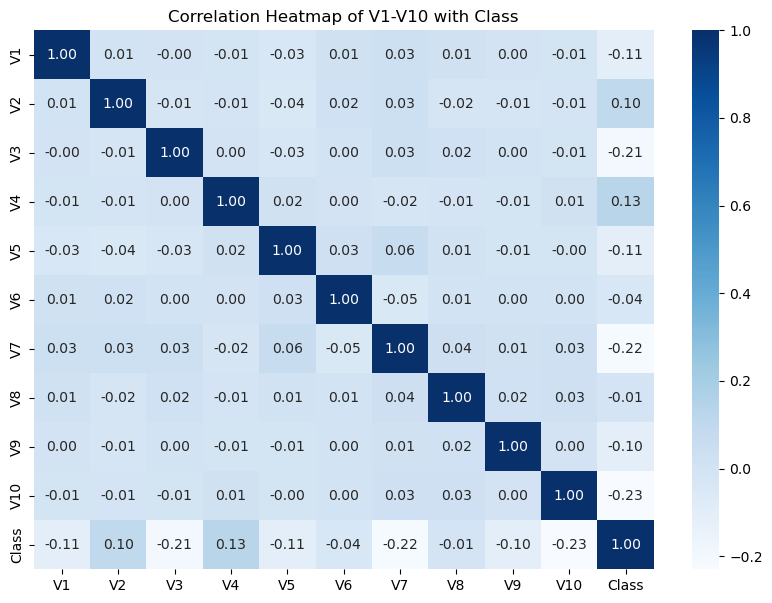

In [412]:
corr=sample[[f'V{i}' for i in range(1,11)]+['Class']].corr()

plt.figure(figsize=(10, 7))
# sns.heatmap(corr, cmap="Blues", center=0, annot=False, fmt=".2f")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")

plt.title("Correlation Heatmap of V1-V10 with Class")
plt.show()

## Step 3: Feature Engineering & Preprocessing

In [413]:
sample['Amount_log']=np.log1p(sample['Amount'])
sample['Hour']=(sample['Time']%86400)//3600
sample=sample.drop(columns=['Time','Amount'])

X=sample.drop('Class',axis=1)
y=sample['Class']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

scaler=StandardScaler()
cols=['Amount_log','Hour']
X_train[cols]=scaler.fit_transform(X_train[cols])
X_test[cols]=scaler.transform(X_test[cols])

sm=SMOTE(random_state=42,sampling_strategy=0.1)
X_sm,y_sm=sm.fit_resample(X_train,y_train)

ru=RandomUnderSampler(random_state=42,sampling_strategy=0.1)
X_un,y_un=ru.fit_resample(X_train,y_train)

X_sm.shape
y_sm.value_counts()
print("Original Train Shape:", X_train.shape)
print("Original Test Shape:", X_test.shape)

print("\nOriginal Class Distribution:")
print(y_train.value_counts())

print("\nSMOTE Shape:")
print(X_sm.shape)
print(y_sm.value_counts())

print("\nRandom Undersampling Shape:")
print(X_un.shape)
print(y_un.value_counts())

Original Train Shape: (40000, 30)
Original Test Shape: (10000, 30)

Original Class Distribution:
Class
0    39931
1       69
Name: count, dtype: int64

SMOTE Shape:
(43924, 30)
Class
0    39931
1     3993
Name: count, dtype: int64

Random Undersampling Shape:
(759, 30)
Class
0    690
1     69
Name: count, dtype: int64


## Step 4: Logistic Regression & Random Forest

In [414]:
results = []

# Function to evaluate model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)

    results.append([name, precision, recall, f1, pr_auc])

# -----------------------------
# Logistic Regression - Original Data
# -----------------------------
lr_original = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_original.fit(X_train, y_train)
evaluate_model("Original", lr_original, X_test, y_test)

# -----------------------------
# Logistic Regression - SMOTE Data
# -----------------------------
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(X_sm, y_sm)
evaluate_model("SMOTE", lr_smote, X_test, y_test)

# -----------------------------
# Logistic Regression - Undersampled Data
# -----------------------------
lr_under = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_under.fit(X_un, y_un)
evaluate_model("Undersampling", lr_under, X_test, y_test)

# -----------------------------
# Comparison Table
# -----------------------------
comparison_lr = pd.DataFrame(
    results,
    columns=[
        "Strategy",
        "Precision",
        "Recall",
        "F1 Score",
        "PR-AUC"
    ]
)

comparison_lr

,Strategy,Precision,Recall,F1 Score,PR-AUC
0,Original,0.064885,1.000000,0.121864,0.781376
1,SMOTE,0.309091,1.000000,0.472222,0.814363
2,Undersampling,0.228571,0.941176,0.367816,0.809281


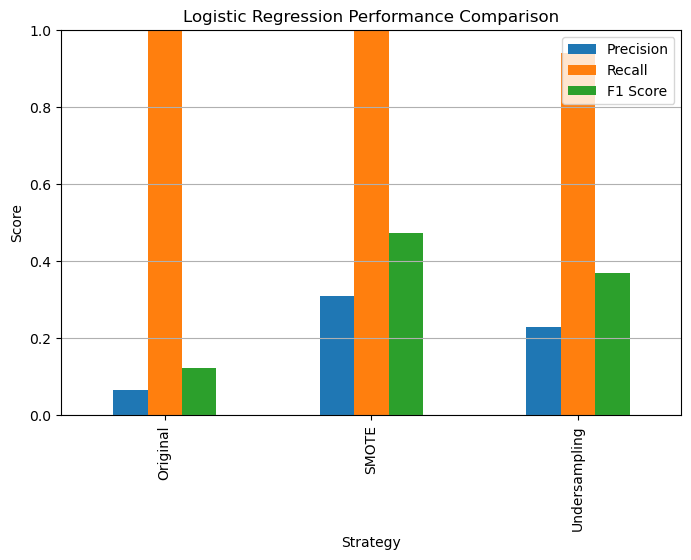

In [415]:
comparison_lr.plot(
    x="Strategy",
    y=["Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Logistic Regression Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

In [416]:
best_strategy = comparison_lr.sort_values(
    by="PR-AUC",
    ascending=False
).iloc[0]["Strategy"]

print(best_strategy)

SMOTE


In [417]:
if best_strategy == "Original":
    X_best = X_train
    y_best = y_train

elif best_strategy == "SMOTE":
    X_best = X_sm
    y_best = y_sm

else:
    X_best = X_un
    y_best = y_un

print("Best Strategy:", best_strategy)
print(X_best.shape)
print(y_best.value_counts())

Best Strategy: SMOTE
(43924, 30)
Class
0    39931
1     3993
Name: count, dtype: int64


In [418]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_best, y_best)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("Precision :", precision_score(y_test, rf_pred))
print("Recall    :", recall_score(y_test, rf_pred))
print("F1 Score  :", f1_score(y_test, rf_pred))
print("PR-AUC    :", average_precision_score(y_test, rf_prob))

Precision : 0.9333333333333333
Recall    : 0.8235294117647058
F1 Score  : 0.875
PR-AUC    : 0.890389856203005


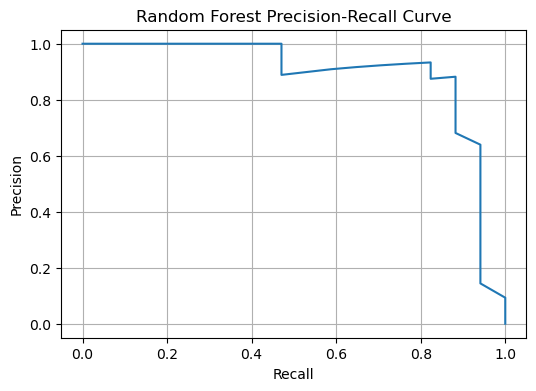

In [419]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.grid(True)
plt.show()

   Feature  Importance
13     V14    0.201628
9      V10    0.122431
16     V17    0.108907
11     V12    0.081202
10     V11    0.074833
3       V4    0.070460
15     V16    0.039718
2       V3    0.033140
1       V2    0.032186
8       V9    0.031007


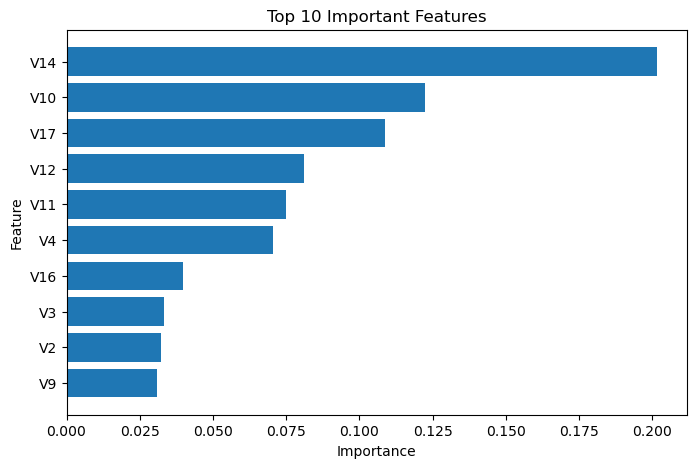

In [420]:
feature_importance = pd.DataFrame({
    "Feature": X_best.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))


plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Step 5: XGBoost + Threshold Optimisation

In [421]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost Baseline
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# Prediction
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

# Metrics
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Precision : 1.0
Recall    : 0.8235294117647058
F1 Score  : 0.9032258064516129
PR-AUC    : 0.896845694799659


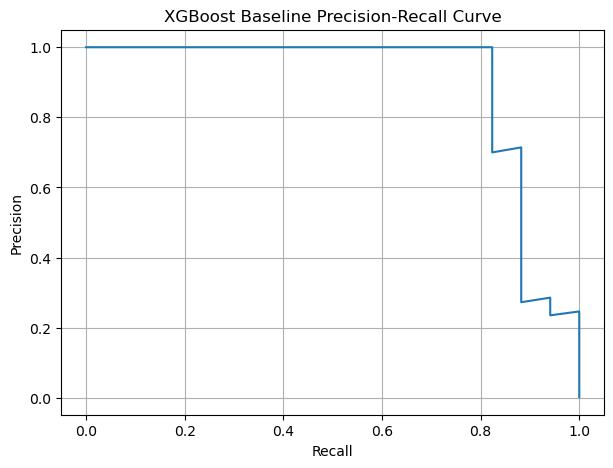

In [422]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Baseline Precision-Recall Curve")
plt.grid(True)
plt.show()

In [423]:
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[3,4,5,6],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.6,0.8,1.0],
    "colsample_bytree":[0.6,0.8,1.0]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best Parameters")
print(search.best_params_)

print("\nBest CV PR-AUC")
print(search.best_score_)

Best Parameters
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV PR-AUC
0.8042548852105508


In [424]:
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:,1]

print("Precision :", precision_score(y_test, y_pred_tuned))
print("Recall    :", recall_score(y_test, y_pred_tuned))
print("F1 Score  :", f1_score(y_test, y_pred_tuned))
print("PR-AUC    :", average_precision_score(y_test, y_prob_tuned))

Precision : 1.0
Recall    : 0.8235294117647058
F1 Score  : 0.9032258064516129
PR-AUC    : 0.9272173424422561


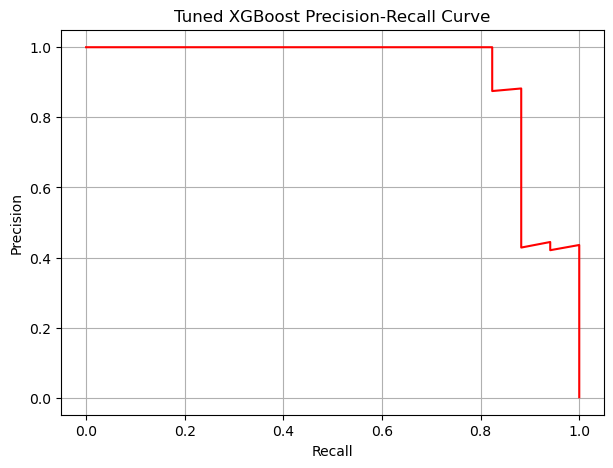

In [425]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_tuned
)

plt.figure(figsize=(7,5))
plt.plot(recall, precision,color="red")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Tuned XGBoost Precision-Recall Curve")
plt.grid(True)
plt.show()

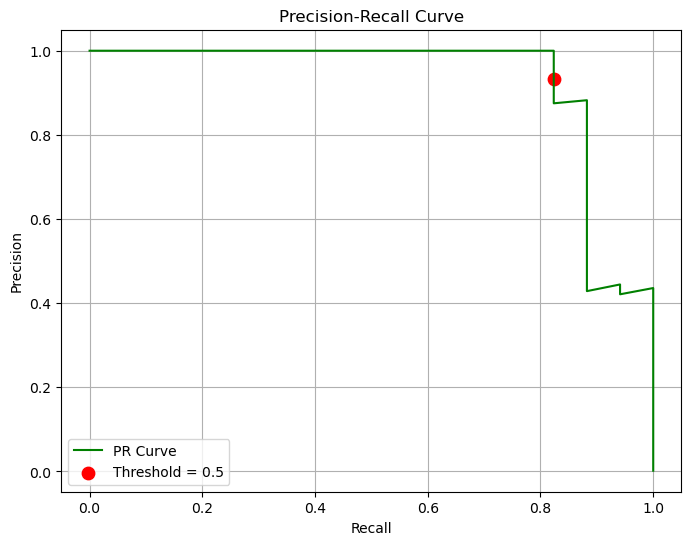

Best F1 Threshold: 0.8805
Recall >= 0.90 Threshold: 0.0041
   Threshold  Precision    Recall  F1 Score    PR-AUC
0   0.500000   1.000000  0.823529  0.903226  0.927217
1   0.880507   1.000000  0.823529  0.903226  0.927217
2   0.004119   0.444444  0.941176  0.603774  0.927217


In [426]:
# Predicted probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Plot PR Curve and mark default threshold (0.5)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label="PR Curve",color="green")

default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(recall[default_idx], precision[default_idx],
            color="red", s=80, label="Threshold = 0.5")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

# Remove last element for threshold calculations
precision = precision[:-1]
recall = recall[:-1]

# Best F1 Threshold
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

# Threshold with Recall >= 0.90 and Highest Precision
valid_idx = np.where(recall >= 0.90)[0]

if len(valid_idx) > 0:
    recall_idx = valid_idx[np.argmax(precision[valid_idx])]
    recall_threshold = thresholds[recall_idx]
else:
    recall_threshold = 0.5

# Predictions
pred_default = (y_prob >= 0.5).astype(int)
pred_best = (y_prob >= best_threshold).astype(int)
pred_recall = (y_prob >= recall_threshold).astype(int)

# Comparison Table
comparison = pd.DataFrame({
    "Threshold":[0.5, best_threshold, recall_threshold],
    "Precision":[
        precision_score(y_test, pred_default),
        precision_score(y_test, pred_best),
        precision_score(y_test, pred_recall)
    ],
    "Recall":[
        recall_score(y_test, pred_default),
        recall_score(y_test, pred_best),
        recall_score(y_test, pred_recall)
    ],
    "F1 Score":[
        f1_score(y_test, pred_default),
        f1_score(y_test, pred_best),
        f1_score(y_test, pred_recall)
    ],
    "PR-AUC":[
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob)
    ]
})

print("Best F1 Threshold:", round(best_threshold, 4))
print("Recall >= 0.90 Threshold:", round(recall_threshold, 4))
print(comparison)



## Step 6: Model Comparison

,Model,Threshold,Precision,Recall,F1 Score,PR-AUC
0,Logistic Regression,0.500000,0.064885,1.000000,0.121864,0.781376
1,Random Forest,0.500000,0.933333,0.823529,0.875000,0.890390
2,XGBoost Tuned (0.5),0.500000,1.000000,0.823529,0.903226,0.927217
3,XGBoost Tuned (Best F1),0.880507,1.000000,0.823529,0.903226,0.927217
4,XGBoost Tuned (Recall>=0.90),0.004119,0.444444,0.941176,0.603774,0.927217


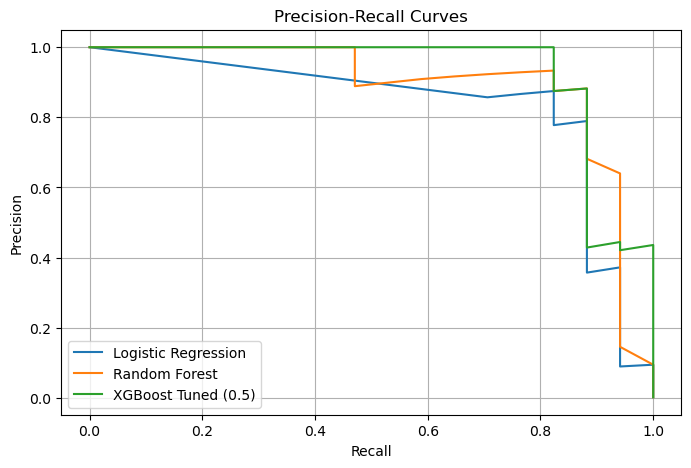


Recommended Model:


Model        XGBoost Tuned (0.5)
Threshold                    0.5
Precision                    1.0
Recall                  0.823529
F1 Score                0.903226
PR-AUC                  0.927217
Name: 2, dtype: object

In [427]:
# Probabilities
lr_prob = lr_original.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = best_model.predict_proba(X_test)[:,1]

models = [
    ("Logistic Regression", lr_prob, 0.5),
    ("Random Forest", rf_prob, 0.5),
    ("XGBoost Tuned (0.5)", xgb_prob, 0.5),
    ("XGBoost Tuned (Best F1)", xgb_prob, best_threshold),
    ("XGBoost Tuned (Recall>=0.90)", xgb_prob, recall_threshold)
]

result = []

for name, prob, th in models:
    pred = (prob >= th).astype(int)
    result.append([
        name,
        th,
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        average_precision_score(y_test,prob)
    ])

comparison = pd.DataFrame(result, columns=[
    "Model","Threshold","Precision","Recall","F1 Score","PR-AUC"
])

display(comparison)

plt.figure(figsize=(8,5))
for name, prob, _ in models[:3]:
    p,r,_=precision_recall_curve(y_test,prob)
    plt.plot(r,p,label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

print("\nRecommended Model:")
display(comparison.loc[comparison["F1 Score"].idxmax()])

In [428]:
recommended_model_name = comparison.sort_values(by=["PR-AUC", "F1 Score"], ascending=False).iloc[0]["Model"]

recommendation_text = f'''
**Recommendation:** Based on PR-AUC, **{recommended_model_name}** is the best model in this notebook.  
Logistic Regression gives a useful baseline, but the tree-based models perform better for fraud detection.  
Random Forest improves the results, but tuned XGBoost gives the strongest overall ranking.  
The default threshold of 0.5 is simple, but threshold tuning gives a better balance between Precision and Recall.  
If the team wants balanced performance, the best F1 threshold is a good option.  
If the team wants to catch more fraud cases, the recall-focused threshold can be used even though it will create more false alarms.
'''

display(Markdown(recommendation_text))


**Recommendation:** Based on PR-AUC, **XGBoost Tuned (0.5)** is the best model in this notebook.  
Logistic Regression gives a useful baseline, but the tree-based models perform better for fraud detection.  
Random Forest improves the results, but tuned XGBoost gives the strongest overall ranking.  
The default threshold of 0.5 is simple, but threshold tuning gives a better balance between Precision and Recall.  
If the team wants balanced performance, the best F1 threshold is a good option.  
If the team wants to catch more fraud cases, the recall-focused threshold can be used even though it will create more false alarms.


## Step 7: Cost Benefit Analysis

In [429]:
thresholds = [0.1, 0.2, 0.3, 0.5, best_threshold]

results = []

for threshold in thresholds:

    y_pred = (tuned_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    money_saved = tp * 4500
    investigation_cost = (tp + fp) * 150
    money_lost = fn * 4500
    net_benefit = money_saved - investigation_cost

    results.append([
        round(threshold,3),
        tp,
        fp,
        fn,
        money_saved,
        investigation_cost,
        money_lost,
        net_benefit
    ])

business_df = pd.DataFrame(results, columns=[
    "Threshold",
    "TP",
    "FP",
    "FN",
    "Money Saved",
    "Investigation Cost",
    "Money Lost",
    "Net Benefit"
])

display(business_df)

,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,0.100,15,3,2,67500,2700,9000,64800
1,0.200,15,2,2,67500,2550,9000,64950
2,0.300,14,1,3,63000,2250,13500,60750
3,0.500,14,0,3,63000,2100,13500,60900
4,0.881,14,0,3,63000,2100,13500,60900


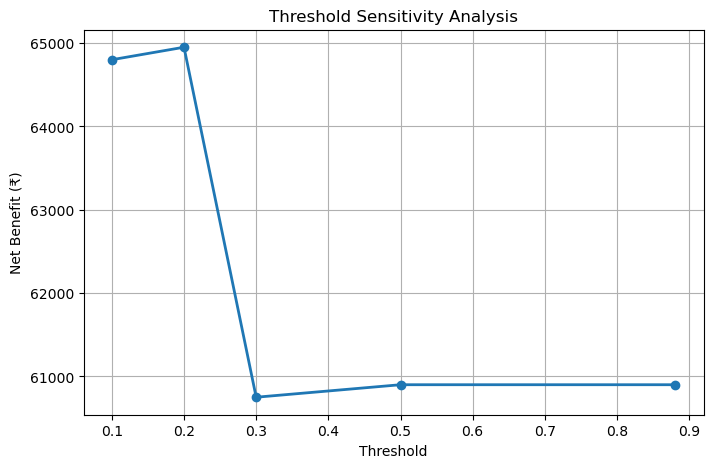

In [430]:
plt.figure(figsize=(8,5))

plt.plot(
    business_df["Threshold"],
    business_df["Net Benefit"],
    marker="o",
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Net Benefit (₹)")
plt.title("Threshold Sensitivity Analysis")
plt.grid(True)

plt.show()

In [431]:
best_business = business_df.loc[business_df["Net Benefit"].idxmax()]

print("Best Threshold :", best_business["Threshold"])
print("Highest Net Benefit :", best_business["Net Benefit"])

print("\nInterpretation:")
best= f'''
1. he threshold with the highest Net Benefit should be selected for deployment.
      
2. A lower threshold catches more fraud but increases investigation cost.

3. The business-optimal threshold may differ from the F1-optimal threshold.'''
display(Markdown(best))

Best Threshold : 0.2
Highest Net Benefit : 64950.0

Interpretation:



1. he threshold with the highest Net Benefit should be selected for deployment.
      
2. A lower threshold catches more fraud but increases investigation cost.

3. The business-optimal threshold may differ from the F1-optimal threshold.

## Step 8: Save Pipeline

In [436]:
pipeline = Pipeline([
    ("model", best_model)
])

joblib.dump(pipeline, "fraud_detection_model.pkl")

print("Pipeline Saved Successfully!")

Pipeline Saved Successfully!


In [437]:
loaded_model = joblib.load("fraud_detection_model.pkl")

sample = X_test.head(10)

prob = loaded_model.predict_proba(sample)[:,1]
pred = (prob >= best_threshold).astype(int)

result = sample.copy()
result["Fraud Probability"] = prob
result["Predicted Label"] = pred

display(result)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount_log,Hour,Fraud Probability,Predicted Label
239714,1.887998,-0.502715,-2.139380,0.540035,2.276230,4.078953,-0.639859,0.992174,0.967097,0.000540,...,0.249721,0.668968,0.084076,-0.801250,0.052852,-0.045127,0.257061,0.499089,2.715079e-07,0
157810,-0.517028,0.889183,-0.074554,-0.126834,1.106466,-0.293385,0.751862,-0.167153,1.178160,-1.145768,...,-0.199270,0.680229,-0.628372,0.199552,-0.068097,0.230990,0.320054,-1.388263,2.146604e-06,0
148714,2.065915,0.139998,-1.093051,0.559314,0.087705,-1.186383,0.147847,-0.484861,1.810307,-0.388414,...,0.010196,-0.016236,0.240267,-0.139699,-0.034916,-0.063009,-1.491789,-2.246150,6.440020e-06,0
214926,-0.361801,1.059910,-0.967156,-0.598057,0.777058,-0.769390,0.400614,0.375428,-0.547273,-0.910573,...,-0.093037,0.643737,-0.551593,0.489011,-0.203136,0.046318,-1.665854,-0.015644,5.085102e-05,0
180178,-0.365774,-0.404755,0.185328,-1.993902,0.076907,-0.365459,0.740141,-0.013005,-1.495785,0.128049,...,0.386111,0.642332,-0.629973,-0.566811,0.089472,0.191499,1.079456,-0.701953,1.140903e-06,0
145638,-0.442864,1.309549,-0.865736,1.206025,0.306677,-1.063431,0.617714,-0.144158,-0.124882,0.271693,...,-0.017760,-0.045401,-0.868473,0.150123,0.264070,0.167420,0.164435,-2.417727,1.504846e-04,0
83517,-1.235013,1.249045,1.443106,1.543345,-1.011791,0.831999,-0.740069,1.176808,0.130884,-0.603321,...,0.009771,0.005511,-0.288411,-0.484831,-0.302454,0.013532,-0.461965,0.327511,4.082756e-06,0
109187,1.206657,0.351803,0.207850,1.120606,-0.053078,-0.545475,0.257974,-0.136996,-0.256709,0.087041,...,-0.169123,0.380041,0.842983,-0.296627,0.012252,0.004740,-1.491789,0.842244,6.695698e-06,0
249939,-0.659112,0.963787,0.058881,-1.158321,1.786200,-0.511605,1.400378,-0.450033,-0.170887,-0.956661,...,-0.097664,0.007158,-0.132305,0.042242,-0.374950,-0.031882,-1.250505,0.670666,8.322651e-07,0
90697,-3.717039,2.886631,-0.139779,-1.914633,-1.210240,-0.593823,-0.504517,1.266138,1.625950,2.191274,...,0.241630,-0.041646,0.056482,0.777544,0.934341,0.629323,-1.565707,0.499089,1.454707e-06,0


In [434]:
pipe=Pipeline([('model',best_model)])
joblib.dump(pipe,'fraud_detection_model.pkl')
print('Saved fraud_detection_model.pkl')

import pkg_resources

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "imbalanced-learn",
    "xgboost",
    "joblib"
]

with open("requirements.txt", "w") as f:
    for package in packages:
        try:
            f.write(f"{package}=={pkg_resources.get_distribution(package).version}\n")
        except:
            f.write(f"{package}\n")

print("requirements.txt created.")

Saved fraud_detection_model.pkl
requirements.txt created.


In [435]:
summary_report_text = f"""# Summary Report

This project is about finding fraudulent credit card transactions using supervised learning. The dataset is highly imbalanced, so accuracy is not a reliable metric here. A model can get a very high accuracy score by predicting almost every transaction as legitimate, but that would not help the business. Because of that, I used PR-AUC as the main metric and also checked Precision, Recall, and F1-score for the fraud class.

For local execution, I created a stratified sample of 50,000 rows so that the fraud ratio stays close to the original dataset. In the EDA step, I checked the class imbalance, transaction amount, transaction time, and correlation of some PCA-based features with the fraud label. The countplot clearly showed how rare fraud cases are. The amount and time plots also helped in understanding that fraud transactions can behave differently from normal ones, which supports the need for proper feature engineering and threshold tuning.

In preprocessing, I created two required features: `Amount_log` from the `Amount` column and `Hour` from the `Time` column. `Amount_log` helped reduce the skewness in transaction amount, while `Hour` captured the hour of the day from transaction time. After creating these features, I removed the original `Time` and `Amount` columns. I scaled only `Amount_log` and `Hour` because the `V1` to `V28` columns are already PCA-transformed and do not need the same treatment.

To handle the imbalance problem, I trained Logistic Regression in three ways: original training data with `class_weight='balanced'`, SMOTE, and Random Undersampling. I compared them using PR-AUC and then used the best imbalance strategy for Random Forest. After that, I trained a baseline XGBoost model with `scale_pos_weight` and then tuned it using `RandomizedSearchCV`. Among all the models tested, tuned XGBoost gave the best overall performance and the strongest ranking power on fraud cases.

Threshold selection was also very important. A default threshold of 0.5 is easy to use, but it is not always best for fraud detection. I found one threshold that gave the best F1-score and another threshold that kept Recall at or above 0.90. This showed that the same model can behave very differently depending on the threshold. In the business cost analysis, I used INR 4,500 as fraud value and INR 150 as investigation cost. The highest net benefit came at threshold {threshold:.4f}. In a real system, I would improve this project by adding real-time scoring, drift monitoring, periodic retraining, and a feedback loop from the fraud review team.
"""

Path("summary_report.md").write_text(summary_report_text.strip() + "\n", encoding="utf-8")

print("summary_report.md created.")
print("Summary report word count:", len(summary_report_text.split()))

summary_report.md created.
Summary report word count: 407
